In [ ]:
import os
from helpers import zenodo_get_and_unzip
from pathlib import Path
import pandas as pd
import os
import fmlib.io as fmio

save_images = False
data_folder = Path('download')
embeddings_folder = data_folder / Path('embeddings')
learned_models_nn_folder = data_folder / Path('learned_models_nn')
learned_models_svm_folder = data_folder / Path('learned_models_svm')
os.makedirs(data_folder, exist_ok=True)

if not embeddings_folder.exists():
    os.makedirs(embeddings_folder)
    zenodo_get_and_unzip('17898581','embeddings.zip','download')

if not learned_models_svm_folder.exists():
    os.makedirs(learned_models_svm_folder)
    zenodo_get_and_unzip('17898581','learned_models_svm.zip','download')

if not learned_models_nn_folder.exists():
    os.makedirs(learned_models_nn_folder)
    zenodo_get_and_unzip('17898581','learned_models_nn.zip','download')

nt_train = fmio.load_fusion_embeddings(embeddings_folder/'nt_mean_train_seq1.csv', embeddings_folder/'nt_mean_train_seq2.csv', embeddings_folder/'fusionai_train_target.csv')
evo_train = fmio.load_fusion_embeddings(embeddings_folder/'evo_mean_train_seq1.csv', embeddings_folder/'evo_mean_train_seq2.csv', embeddings_folder/'fusionai_train_target.csv')
hyena_train = fmio.load_fusion_embeddings(embeddings_folder/'hyena_mean_train_seq1.csv', embeddings_folder/'hyena_mean_train_seq2.csv', embeddings_folder/'fusionai_train_target.csv')
bert_train = fmio.load_fusion_embeddings(embeddings_folder/'bert_mean_train_seq1.csv', embeddings_folder/'bert_mean_train_seq2.csv', embeddings_folder/'fusionai_train_target.csv')

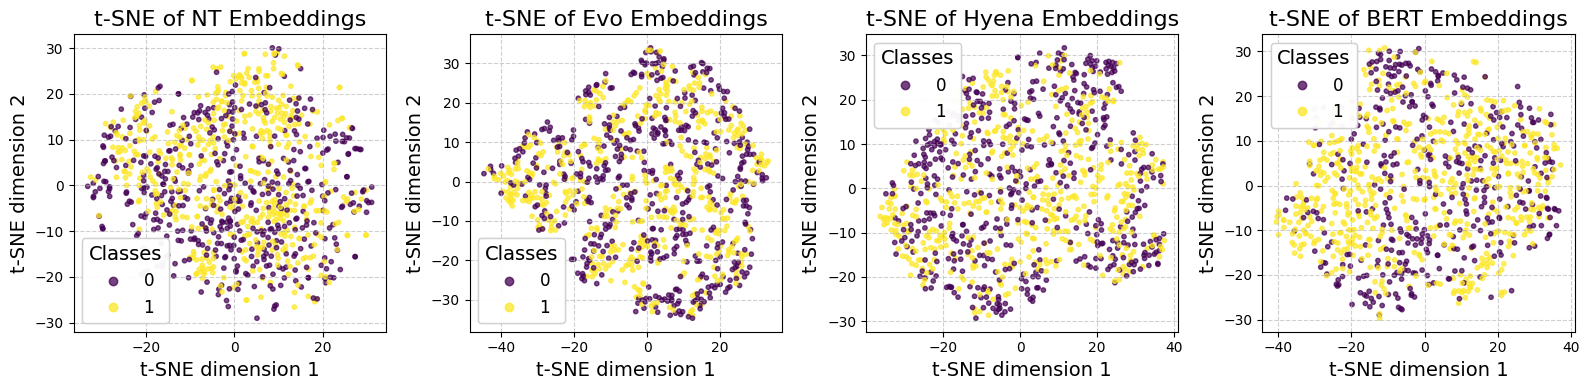

In [ ]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# Extract vectors and responses for each model
nt_train_vector = nt_train[0]
nt_response = np.argmax(nt_train[1], axis=1)
evo_train_vector = evo_train[0]
evo_response = np.argmax(evo_train[1], axis=1)
hyena_train_vector = hyena_train[0]
hyena_response = np.argmax(hyena_train[1], axis=1)
bert_train_vector = bert_train[0]
bert_response = np.argmax(bert_train[1], axis=1)

# Combine data for t-SNE processing
embeddings = {
    'NT': nt_train_vector,
    'Evo': evo_train_vector,
    'Hyena': hyena_train_vector,
    'BERT': bert_train_vector
}
responses = {
    'NT': nt_response,
    'Evo': evo_response,
    'Hyena': hyena_response,
    'BERT': bert_response
}

# Initialize t-SNE
tsne = TSNE(n_components=2, random_state=42)

# Create 2x2 subplots
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes = axes.ravel()

# Generate and plot t-SNE for each embedding
for i, (name, vector) in enumerate(embeddings.items()):
    # To speed up, let's use a subset of the data for t-SNE
    sample_size = 1000
    indices = np.random.choice(vector.shape[0], sample_size, replace=False)
    
    tsne_results = tsne.fit_transform(vector[indices])
    ax = axes[i]
    scatter = ax.scatter(tsne_results[:, 0], tsne_results[:, 1], c=responses[name][indices], cmap='viridis', alpha=0.7, s=10)
    
    # Set titles and labels with increased font size for publication
    ax.set_title(f't-SNE of {name} Embeddings', fontsize=16)
    ax.set_xlabel('t-SNE dimension 1', fontsize=14)
    ax.set_ylabel('t-SNE dimension 2', fontsize=14)
    
    # Add a grid
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Create and customize the legend
    legend1 = ax.legend(*scatter.legend_elements(), title="Classes", fontsize=12)
    legend1.get_title().set_fontsize('14') # Set legend title font size
    ax.add_artist(legend1)

plt.tight_layout()
# Save the figure for publication in both vector (SVG) and raster (PNG) formats

plt.show()
if save_images:
    fig.savefig('tsne_mean_embeddings_comparison.svg', format='svg', bbox_inches='tight')
    fig.savefig('tsne_mean_embeddings_comparison.png', dpi=300, bbox_inches='tight')



In [11]:
import pickle


# Define prefixes and file paths
prefixes = ['fusionai', 'nt_mean', 'evo_mean', 'hyena_mean', 'bert_mean']

results = {}
histories = {}

for prefix in prefixes:
    # Load results
    results_path =learned_models_nn_folder / Path(f'{prefix}_results_36302.pkl')
    print(f"Loading results from: {results_path}")
    with open(results_path, 'rb') as f:
        results[f'{prefix}_nn'] = pickle.load(f)

for prefix in prefixes:
    # Load histories
    history_path =learned_models_nn_folder / Path(f'{prefix}_history_36302.pkl')
    print(f"Loading history from: {history_path}")
    with open(history_path, 'rb') as f:
        histories[prefix] = pickle.load(f)
            


print("Loaded results and histories for prefixes:", prefixes)


# Create a DataFrame for better visualization




Loading results from: download/learned_models_nn/fusionai_results_36302.pkl
Loading results from: download/learned_models_nn/nt_mean_results_36302.pkl
Loading results from: download/learned_models_nn/evo_mean_results_36302.pkl
Loading results from: download/learned_models_nn/hyena_mean_results_36302.pkl
Loading results from: download/learned_models_nn/bert_mean_results_36302.pkl
Loading history from: download/learned_models_nn/fusionai_history_36302.pkl
Loading history from: download/learned_models_nn/nt_mean_history_36302.pkl
Loading history from: download/learned_models_nn/evo_mean_history_36302.pkl
Loading history from: download/learned_models_nn/hyena_mean_history_36302.pkl
Loading history from: download/learned_models_nn/bert_mean_history_36302.pkl
Loaded results and histories for prefixes: ['fusionai', 'nt_mean', 'evo_mean', 'hyena_mean', 'bert_mean']


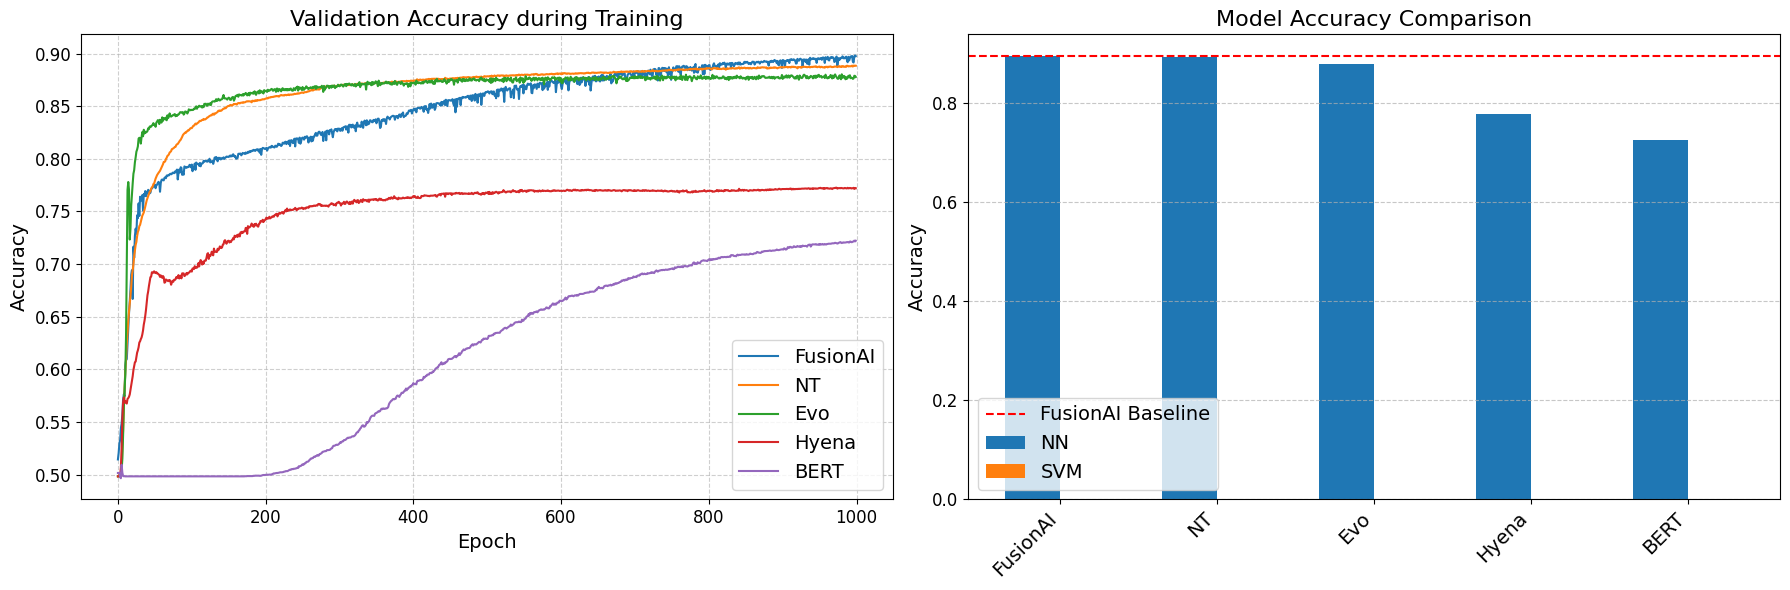


Model Evaluation Summary Table:


,Accuracy,Precision,Recall,F1 Score,ROC AUC
fusionai_nn,0.894,0.894,0.894,0.894,0.960
nt_mean_nn,0.893,0.893,0.893,0.893,0.958
evo_mean_nn,0.879,0.879,0.879,0.879,0.948
hyena_mean_nn,0.777,0.777,0.777,0.777,0.852
bert_mean_nn,0.726,0.748,0.726,0.720,0.819


In [12]:
import numpy as np

import matplotlib.pyplot as plt

evaluation_df = pd.DataFrame.from_dict(results, orient='index')
# Normalize accuracy to be in [0, 1] range
evaluation_df['Accuracy'] = evaluation_df['Accuracy'].apply(lambda x: x / 100 if x > 1 else x)
model_names = ['FusionAI','NT', 'Evo', 'Hyena','BERT','SVM']


def plot_validation_accuracy(ax, histories_dict, model_names):
    """Plots validation accuracy on a given Axes object."""
    history_objs = list(histories_dict.values())
    for i, history in enumerate(history_objs):
        if 'val_accuracy' in history.history:
            ax.plot(history.history['val_accuracy'], label=f'{model_names[i]}')
    ax.set_title('Validation Accuracy during Training', fontsize=16)
    ax.set_xlabel('Epoch', fontsize=14)
    ax.set_ylabel('Accuracy', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='both', which='minor', labelsize=10)
    ax.legend(fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    

def plot_accuracy_bar(ax, evaluation_df, model_names, prefixes):
    """Plots a grouped bar chart of model accuracies on a given Axes object."""
    nn_accuracies = []
    svm_accuracies = []

    for prefix in prefixes:
        nn_accuracies.append(evaluation_df.loc[f'{prefix}_nn', 'Accuracy'])
        svm_key = f'{prefix}_svm'
        if svm_key in evaluation_df.index:
            svm_accuracies.append(evaluation_df.loc[svm_key, 'Accuracy'])
        else:
            svm_accuracies.append(0) # Use 0 for missing SVM models for plotting

    x = np.arange(len(prefixes))
    width = 0.35
    ax.bar(x - width/2, nn_accuracies, width, label='NN')
    ax.bar(x + width/2, svm_accuracies, width, label='SVM')

    # Add a horizontal line for the first model's accuracy as a baseline
    if nn_accuracies:
        baseline_accuracy = nn_accuracies[0]
        ax.axhline(y=baseline_accuracy, color='r', linestyle='--', label=f'{model_names[0]} Baseline')

    ax.set_ylabel('Accuracy', fontsize=14)
    ax.set_title('Model Accuracy Comparison', fontsize=16)
    ax.set_xticks(x)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='both', which='minor', labelsize=10)
    ax.set_xticklabels(model_names[:len(prefixes)], rotation=45, ha="right", fontsize=14)
    ax.legend(fontsize=14, loc='lower left')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
     # Adjust ylim to focus on the relevant accuracy range
    




# --- Main Execution ---

# Define the order for displaying results
ordered_index = [
    'fusionai_nn',
    'nt_mean_nn',
    'evo_mean_nn',
    'hyena_mean_nn',
    'bert_mean_nn',

]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Subplot 1: Validation Accuracy
plot_validation_accuracy(axes[0], histories, model_names)

# Subplot 2: Grouped Bar Plot for Model Accuracy Comparison
plot_accuracy_bar(axes[1], evaluation_df, model_names, prefixes)

plt.tight_layout()
plt.show()
if save_images:
    fig.savefig('model_performance_comparison.svg', format='svg', bbox_inches='tight')
    fig.savefig('model_performance_comparison.png', dpi=300, bbox_inches='tight')

# Display the evaluation summary table
print("\nModel Evaluation Summary Table:")
display(evaluation_df.loc[ordered_index, ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']].round(3))